In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [ ]:
# Load dataset (Download Telco Customer Churn dataset from Kaggle)
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values (Correct way)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
binary_cols = ["gender", "Partner", "Dependents",
               "PhoneService", "PaperlessBilling"]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
scaler = MinMaxScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5282, 30)
Testing size: (1761, 30)


In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("----------------------------------------------------")

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Logistic Regression Results")
evaluate_model(lr, X_test, y_test)

Logistic Regression Results
Accuracy: 0.8012492901760363
Precision: 0.6503856041131105
Recall: 0.5417558886509636
F1 Score: 0.5911214953271028
ROC-AUC: 0.8455050322853955

Confusion Matrix:
 [[1158  136]
 [ 214  253]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1294
           1       0.65      0.54      0.59       467

    accuracy                           0.80      1761
   macro avg       0.75      0.72      0.73      1761
weighted avg       0.79      0.80      0.80      1761

----------------------------------------------------


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNN Results")
evaluate_model(knn, X_test, y_test)

KNN Results
Accuracy: 0.7546848381601363
Precision: 0.5374732334047109
Recall: 0.5374732334047109
F1 Score: 0.5374732334047109
ROC-AUC: 0.7779233093606135

Confusion Matrix:
 [[1078  216]
 [ 216  251]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1294
           1       0.54      0.54      0.54       467

    accuracy                           0.75      1761
   macro avg       0.69      0.69      0.69      1761
weighted avg       0.75      0.75      0.75      1761

----------------------------------------------------


In [ ]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)

print("SVM Results")
evaluate_model(svm, X_test, y_test)

SVM Results
Accuracy: 0.7915956842703009
Precision: 0.6388888888888888
Recall: 0.4925053533190578
F1 Score: 0.5562273276904474
ROC-AUC: 0.8079540226841723

Confusion Matrix:
 [[1164  130]
 [ 237  230]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1294
           1       0.64      0.49      0.56       467

    accuracy                           0.79      1761
   macro avg       0.73      0.70      0.71      1761
weighted avg       0.78      0.79      0.78      1761

----------------------------------------------------


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree Results")
evaluate_model(dt, X_test, y_test)

Decision Tree Results
Accuracy: 0.7353776263486655
Precision: 0.5010706638115632
Recall: 0.5010706638115632
F1 Score: 0.5010706638115632
ROC-AUC: 0.6605052474110455

Confusion Matrix:
 [[1061  233]
 [ 233  234]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82      1294
           1       0.50      0.50      0.50       467

    accuracy                           0.74      1761
   macro avg       0.66      0.66      0.66      1761
weighted avg       0.74      0.74      0.74      1761

----------------------------------------------------


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest Results")
evaluate_model(rf, X_test, y_test)

Random Forest Results
Accuracy: 0.7893242475865985
Precision: 0.635593220338983
Recall: 0.4817987152034261
F1 Score: 0.5481120584652862
ROC-AUC: 0.8294202529215718

Confusion Matrix:
 [[1165  129]
 [ 242  225]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1294
           1       0.64      0.48      0.55       467

    accuracy                           0.79      1761
   macro avg       0.73      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761

----------------------------------------------------


                           Feature  Importance
8                     TotalCharges    0.199284
7                   MonthlyCharges    0.169485
4                           tenure    0.169119
28  PaymentMethod_Electronic check    0.039412
11     InternetService_Fiber optic    0.035999
0                           gender    0.028612
6                 PaperlessBilling    0.027602
26               Contract_Two year    0.027294
14              OnlineSecurity_Yes    0.024917
20                 TechSupport_Yes    0.024268


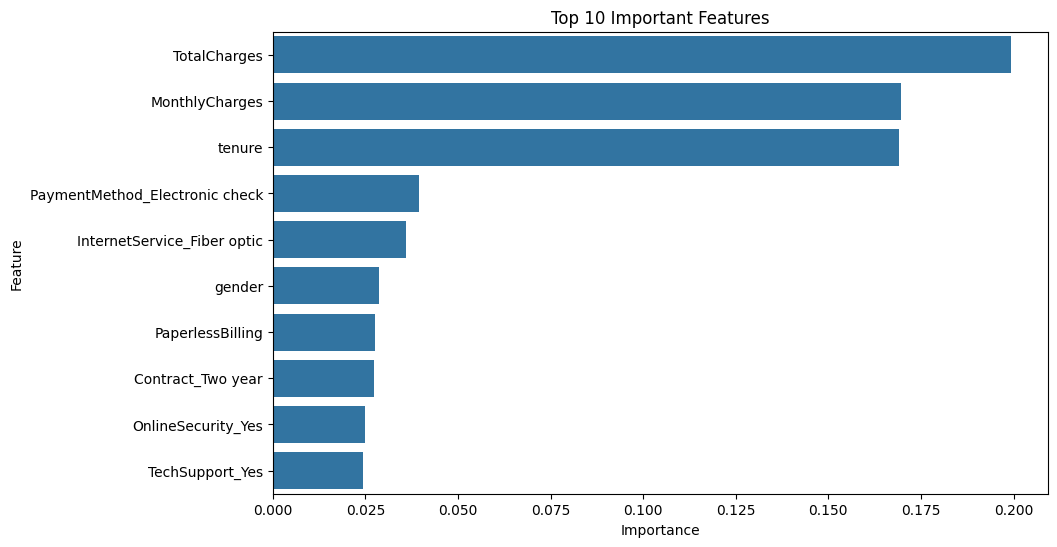

In [ ]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

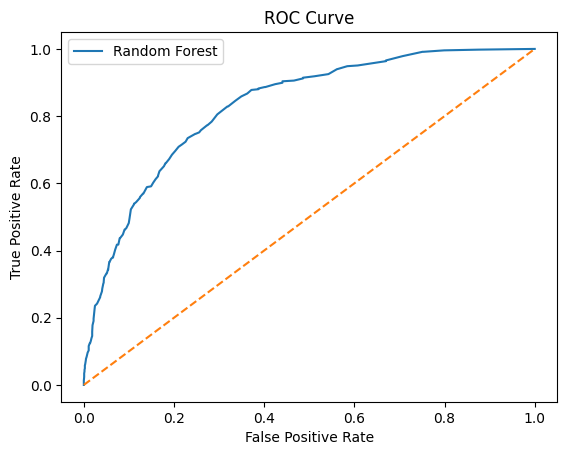

In [ ]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()